In [127]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import os

In [128]:
df = pd.read_csv(f"{os.getcwd()}\\tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## 💹 EDA

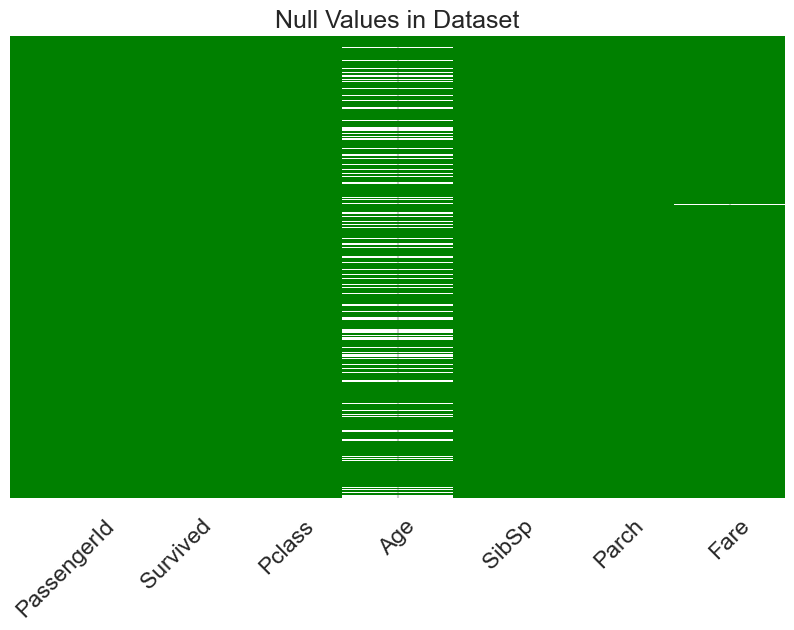

In [129]:
null = df.select_dtypes(exclude="object")
plt.figure(figsize=(10,6))
plt.title("Null Values in Dataset")
sns.heatmap(null.to_numpy(),cbar=False,annot=False,cmap=["green"],xticklabels=null.columns,yticklabels="")
plt.xticks(rotation = 45)
plt.show()

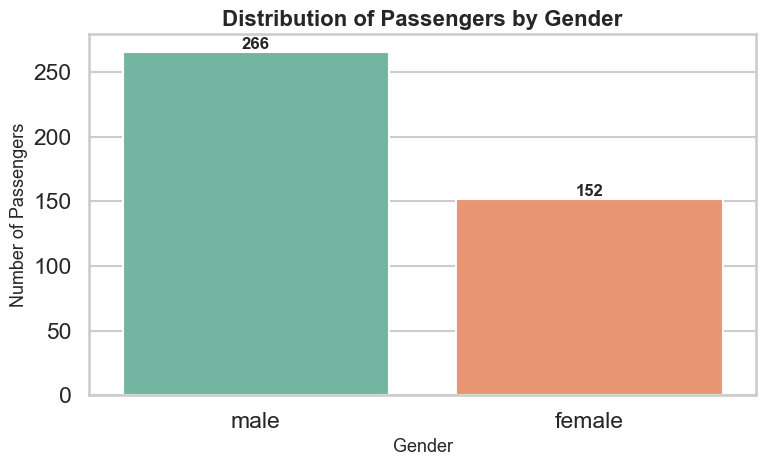

In [130]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,x="Sex",palette="Set2",hue="Sex")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',(p.get_x() + p.get_width() / 2., p.get_height()), ha='center',va='bottom',fontsize=12,fontweight='bold')

plt.title("Distribution of Passengers by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Number of Passengers", fontsize=13)

plt.tight_layout()
plt.show()

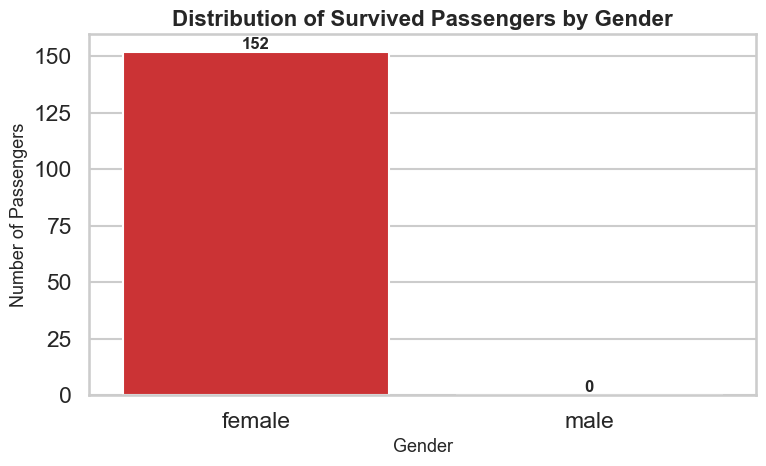

In [131]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(8,5))

data = df.groupby("Sex").sum()

ax = sns.barplot(data=data,x="Sex",y="Survived",palette="Set1",hue="Sex")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',(p.get_x() + p.get_width() / 2., p.get_height()), ha='center',va='bottom',fontsize=12,fontweight='bold')

plt.title("Distribution of Survived Passengers by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Number of Passengers", fontsize=13)

plt.tight_layout()
plt.show()

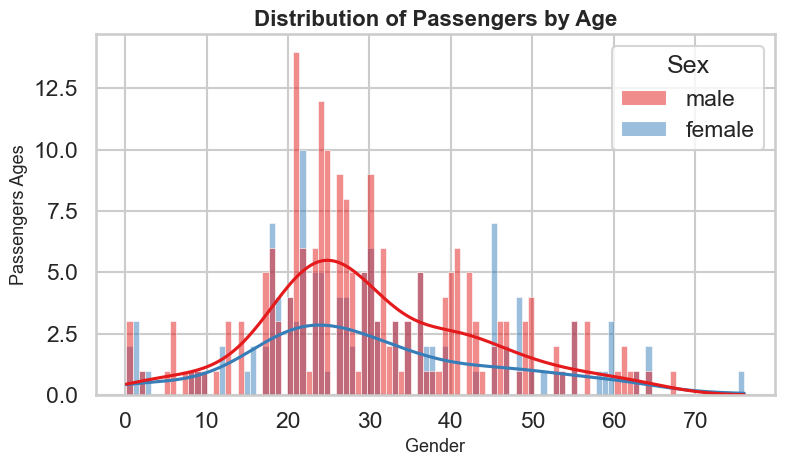

In [132]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(8,5))



ax = sns.histplot(data=df,x="Age",bins=100,kde=True,hue="Sex",palette="Set1")
plt.title("Distribution of Passengers by Age", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Passengers Ages", fontsize=13)

plt.tight_layout()
plt.show()

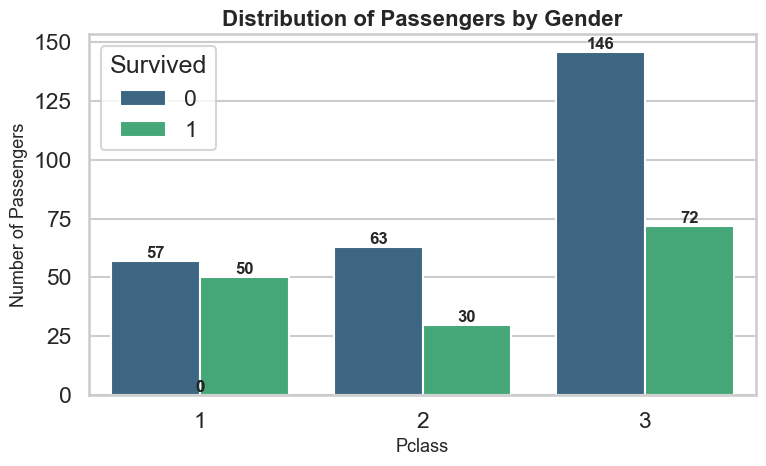

In [133]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,x="Pclass",palette="viridis",hue="Survived")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',(p.get_x() + p.get_width() / 2., p.get_height()), ha='center',va='bottom',fontsize=12,fontweight='bold')

plt.title("Distribution of Passengers by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Pclass", fontsize=13)
plt.ylabel("Number of Passengers", fontsize=13)

plt.tight_layout()
plt.show()

In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [136]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [137]:
f"number of filled cabin rows = {df.shape[0] - df["Cabin"].isnull().sum()}"

'number of filled cabin rows = 91'

In [138]:
df.drop(columns=["Cabin"],inplace=True)

In [139]:
df.select_dtypes(include="object")

,Name,Sex,Ticket,Embarked
0,"Kelly, Mr. James",male,330911,Q
1,"Wilkes, Mrs. James (Ellen Needs)",female,363272,S
2,"Myles, Mr. Thomas Francis",male,240276,Q
3,"Wirz, Mr. Albert",male,315154,S
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,3101298,S
...,...,...,...,...
413,"Spector, Mr. Woolf",male,A.5. 3236,S
414,"Oliva y Ocana, Dona. Fermina",female,PC 17758,C
415,"Saether, Mr. Simon Sivertsen",male,SOTON/O.Q. 3101262,S
416,"Ware, Mr. Frederick",male,359309,S


In [140]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

In [141]:
encoder = LabelEncoder()

df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [142]:
df["Sex"] = encoder.fit_transform(df["Sex"])

In [143]:
for column in ["Age","Fare"]: 
    scaler = StandardScaler()
    df[column] = scaler.fit_transform(df[[column]])

In [144]:
df.drop(columns=["PassengerId","Name","Ticket"],axis=0)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,0.386231,0,0,-0.497811,1
1,1,3,0,1.371370,1,0,-0.512660,2
2,0,2,1,2.553537,0,0,-0.464532,1
3,0,3,1,-0.204852,0,0,-0.482888,2
4,1,3,0,-0.598908,1,1,-0.417971,2
...,...,...,...,...,...,...,...,...
413,0,3,1,-0.204852,0,0,-0.493856,2
414,1,1,0,0.740881,0,0,1.312180,0
415,0,3,1,0.701476,0,0,-0.508183,2
416,0,3,1,-0.204852,0,0,-0.493856,2


In [145]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]


x_train , x_test, y_train, y_test = train_test_split(x,y,random_state=42,shuffle=True,train_size=0.2)